# <center>**LastFM Data Science Project**</center>

## **Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import pylast

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from concurrent.futures import ThreadPoolExecutor, as_completed

from bs4 import BeautifulSoup
import requests

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("Note: umap-learn not installed. Run: pip install umap-learn")
    print("UMAP sections will be skipped.")

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# **Data Preparation**

## **Get API Access**

In [6]:
API_KEY = "2d901b318bd2a5c736ca66d22eadf0ae"
API_SECRET = "daa7b060a8bee7f17c7ba9f88d2f535f"
network = pylast.LastFMNetwork(
    api_key=API_KEY,
    api_secret=API_SECRET
)

# test connection
user = network.get_user('cosmeticstm')
print(user.get_name())

cosmeticstm


## **Get dynamic threshold for limit parameter**

In [8]:
def get_dynamic_threshold(user, fetch_limit=1000, percentile=75):
    '''
    Set threshold at the nth percentile of play counts
    '''
    import numpy as np
    
    top_artists = user.get_top_artists(limit=fetch_limit)
    play_counts = [int(a.weight) for a in top_artists]
    
    threshold = int(np.percentile(play_counts, percentile))
    print(f"Dynamic threshold ({percentile}th percentile): {threshold} plays")
    
    meaningful = [a for a in top_artists if int(a.weight) >= threshold]
    print(f"Artists above threshold: {len(meaningful)}")
    
    return meaningful

play_count = get_dynamic_threshold(user)

Dynamic threshold (75th percentile): 89 plays
Artists above threshold: 251


**Insights:**



## **Get top artists**

In [11]:
def fetch_artist_data(artist):
    '''Fetch data for a single artist, including tags.'''
    try:
        tags = artist.item.get_top_tags(limit=15) # set to any limit
        tag_names = [tag.item.name.lower() for tag in tags]
    except pylast.WSError as e:
        print(f"Could not fetch tags for '{artist.item.name}': {e}")
        tag_names = []

    return {
        'artist_name': artist.item.name,
        'play_count': int(artist.weight),
        'url': artist.item.get_url(),
        'tags': tag_names
    }

def parse_top_artists(top_artists, max_workers=10):
    '''
    Convert top artists to DataFrame format, including top tags.
    Fetches tags concurrently to reduce runtime.
    '''
    results = [None] * len(top_artists)  # preserve order

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_index = {
            executor.submit(fetch_artist_data, artist): i
            for i, artist in enumerate(top_artists)
        }
        for future in as_completed(future_to_index):
            i = future_to_index[future]
            results[i] = future.result()

    return pd.DataFrame(results)

# Usage
top_artists = user.get_top_artists(limit=len(play_count))
artists_df = parse_top_artists(top_artists, max_workers=10)
print(artists_df.head())
print(f'Dataframe Shape: {artists_df.shape}')

     artist_name  play_count                                         url  \
0     Kanye West        7076      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6406  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5854   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4584            https://www.last.fm/music/bladee   
4          Lucki        4210             https://www.last.fm/music/lucki   

                                                tags  
0  [hip-hop, rap, hip hop, rnb, kanye west, gay f...  
1  [trap, hip-hop, rap, emo rap, pop rap, hip hop...  
2  [trap, cloud rap, hip-hop, rap, rage, hip hop,...  
3  [cloud rap, trap, drain, hip-hop, hip hop, emo...  
4  [pop, dance, lucki, swedish, trap, female voca...  
Dataframe Shape: (251, 4)


# **Data Preprocessing**

## **Scrape list of valid tags / genres from MusicBrainz.org**

In [14]:
url = 'https://musicbrainz.org/genres' # URL to be scraped
page = requests.get(url) # use requests library

soup = BeautifulSoup(page.text, 'html') # use BS to read html

In [15]:
# remove comments from genres
for comment in soup.find_all('span', class_='comment'):
    comment.decompose()

genres = soup.find_all('bdi') # find all <bdi> tags 

valid_genres = set(genre.text.lower().strip() for genre in genres)

## **Filter valid genres with tags df** 

In [17]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag in valid_genres]
)
print(artists_df.head())

     artist_name  play_count                                         url  \
0     Kanye West        7076      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6406  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5854   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4584            https://www.last.fm/music/bladee   
4          Lucki        4210             https://www.last.fm/music/lucki   

                                            tags  
0                     [hip hop, pop, electronic]  
1   [trap, emo rap, pop rap, hip hop, cloud rap]  
2        [trap, cloud rap, rage, hip hop, plugg]  
3  [cloud rap, trap, hip hop, emo rap, hyperpop]  
4          [pop, dance, trap, techno, cloud rap]  


## **Check for null tags**

In [19]:
null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(null_tags)
print(f'\nNumber of null tags / genres: {num_null_tags}')

        artist_name  play_count                                         url  \
83   alex_g_offline         347    https://www.last.fm/music/alex_g_offline   
111  jaydes archive         273  https://www.last.fm/music/jaydes%2barchive   
152          yenny*         177        https://www.last.fm/music/yenny%252a   
165    alexgoffline         161      https://www.last.fm/music/alexgoffline   
195  Ligaya Escueta         127  https://www.last.fm/music/ligaya%2bescueta   
220        Kimaurii         105          https://www.last.fm/music/kimaurii   

    tags  
83    []  
111   []  
152   []  
165   []  
195   []  
220   []  

Number of null tags / genres: 6


**Insights:**
- I decided to drop the 7 artists with null tags since `alex_g_offline`, `alexgoffline`, `jaydes archive`, and `yenny*` are unofficial archival accounts, not real artists
- `Ligaya Escueta` and `Kimaurii` are niche artists that didn't have any tag data, and thus won't contribute anything meaningfully to ML.
- `Lil Uzi Vert, Playboi Carti` are artifacts that came from Spotify Local Files scrobbling.

### **Prune null tags**

In [22]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (245, 4)


## **Check for sparse tags**

In [24]:
all_tags = [tag for tags in artists_df['tags'] for tag in tags] # Loops to find each tag in tags column

tag_series = pd.Series(all_tags) # Converts into series
tag_counts = tag_series.value_counts() # Counts how many times tag appears

sparse_tags = set(tag_counts[tag_counts < 5].index)
print(sparse_tags)

{'dance', 'horror punk', 'hypnagogic pop', 'folk punk', 'techno', 'rapcore', 'post-grunge', 'nightcore', 'gospel', 'glitch', 'gothic', 'tarantella', 'opm', 'glitch pop', 'funk metal', 'ethereal wave', 'piano rock', 'chillout', 'trap metal', 'heavy metal', '2-step', 'power pop', 'stoner rock', 'goa trance', 'shibuya-kei', 'minimal synth', 'sigilkore', 'experimental rock', 'metalcore', 'new rave', 'classic rock', 'chillwave', 'drill', 'jangle pop', 'boom bap', 'gothic rock', 'country', 'industrial', 'wave', 'grindcore', 'skate punk', 'instrumental', 'french house', 'desert rock', 'dark plugg', 'progressive', 'dub', 'ghetto house', 'jerk', 'sophisti-pop', 'ambient pop', 'avant-garde jazz', 'j-rock', 'conscious hip hop', 'jump up', 'hardcore hip hop', 'west coast hip hop', 'witch house', 'psychedelic rock', 'dirty south', 'electroclash', 'trip hop', 'idm', 'regalia', 'krautrock', 'geek rock', 'art rock', 'j-pop', 'garage rock', 'downtempo', 'soft rock', 'r&b', 'black metal', 'hyperpop', 'e

### **Remove sparse tags and check null tags**

In [26]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag not in sparse_tags]
) # Checks if tag is not in sparse_tags

print(artists_df[artists_df['tags'].apply(len) == 0]) # Checks artists with null tags

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')

    artist_name  play_count                             url tags
210        Yuke         110  https://www.last.fm/music/yuke   []
Number of null tags / genres: 1


### **Remove null tags**

In [28]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {len(null_tags)}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (244, 4)


## **Feature Engineering**

In [30]:
mlb = MultiLabelBinarizer()
ohe = pd.DataFrame(
    mlb.fit_transform(artists_df['tags']),
    columns=mlb.classes_,
    index=artists_df.index
)

final_df = pd.concat([artists_df, ohe], axis=1)
final_df = final_df.drop('tags', axis=1)
print(f'Final Dataframe Shape: {final_df.shape}')
print(f'Columns:\n{final_df.columns}')

Final Dataframe Shape: (244, 56)
Columns:
Index(['artist_name', 'play_count', 'url', 'alternative metal',
       'alternative rock', 'ambient', 'art pop', 'bedroom pop', 'cloud rap',
       'dream pop', 'electronic', 'emo', 'emo rap', 'emocore', 'experimental',
       'experimental hip hop', 'folk', 'funk', 'gangsta rap', 'grunge',
       'hard rock', 'hardcore punk', 'hip hop', 'horrorcore', 'indie folk',
       'indie pop', 'indie rock', 'lo-fi', 'math rock', 'melodic hardcore',
       'metal', 'midwest emo', 'noise pop', 'nu metal', 'plugg', 'pluggnb',
       'pop', 'pop punk', 'pop rap', 'pop rock', 'post-hardcore', 'post-punk',
       'post-rock', 'psychedelic', 'punk', 'punk rock', 'rage', 'rock',
       'screamo', 'shoegaze', 'singer-songwriter', 'slacker rock', 'slowcore',
       'soul', 'southern hip hop', 'trap'],
      dtype='str')


# **Exploratory Data Analysis (EDA)**

## **Play Count Distribution**

=== Descriptive Statistics ===
Total artists: 244
Max plays: 7076
Min plays: 89
Median plays: 235
Mean plays: 535.14
Std dev: 913.02


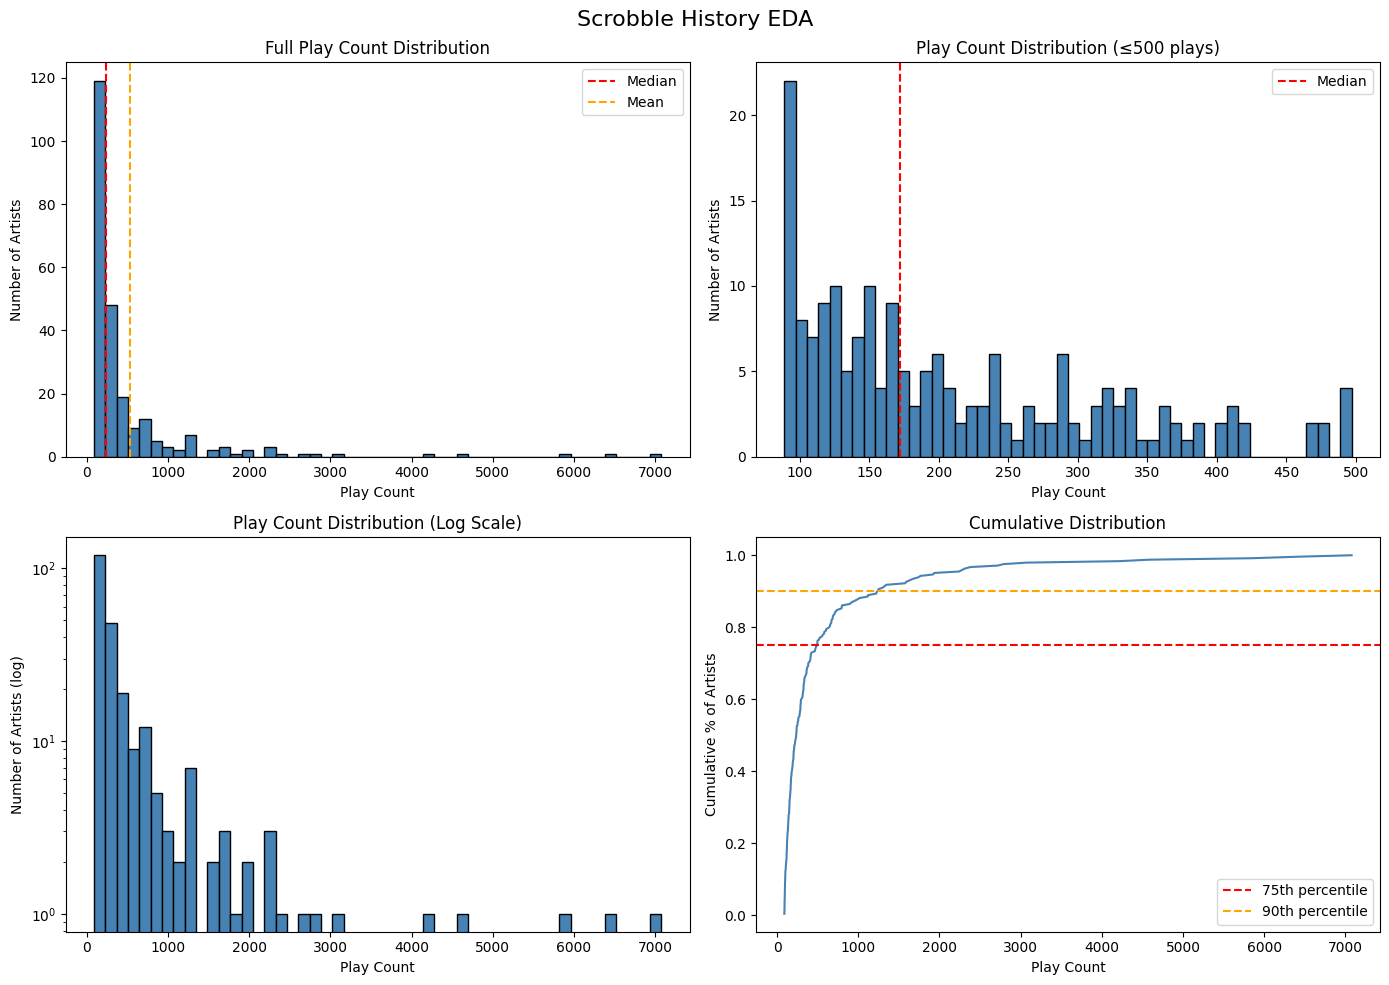

Total artists that exceed 1000: 30


In [33]:
play_counts = artists_df['play_count'].tolist()

# Basic stats
print("=== Descriptive Statistics ===")
print(f"Total artists: {len(play_counts)}")
print(f"Max plays: {max(play_counts)}")
print(f"Min plays: {min(play_counts)}")
print(f"Median plays: {int(np.median(play_counts))}")
print(f"Mean plays: {np.mean(play_counts):.2f}")
print(f"Std dev: {np.std(play_counts):.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scrobble History EDA', fontsize=16)

# 1. Full distribution
axes[0,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Full Play Count Distribution')
axes[0,0].set_xlabel('Play Count')
axes[0,0].set_ylabel('Number of Artists')
axes[0,0].axvline(np.median(play_counts), color='red', linestyle='--', label='Median')
axes[0,0].axvline(np.mean(play_counts), color='orange', linestyle='--', label='Mean')
axes[0,0].legend()

# 2. Zoomed in
zoomed = [p for p in play_counts if p <= 500]
axes[0,1].hist(zoomed, bins=50, color='steelblue', edgecolor='black')
axes[0,1].set_title('Play Count Distribution (≤500 plays)')
axes[0,1].set_xlabel('Play Count')
axes[0,1].set_ylabel('Number of Artists')
axes[0,1].axvline(np.median(zoomed), color='red', linestyle='--', label='Median')
axes[0,1].legend()

# 3. Log scale distribution
axes[1,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black', log=True)
axes[1,0].set_title('Play Count Distribution (Log Scale)')
axes[1,0].set_xlabel('Play Count')
axes[1,0].set_ylabel('Number of Artists (log)')

# 4. Cumulative distribution
sorted_counts = np.sort(play_counts)
cumulative = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1,1].plot(sorted_counts, cumulative, color='steelblue')
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel('Play Count')
axes[1,1].set_ylabel('Cumulative % of Artists')
axes[1,1].axhline(0.75, color='red', linestyle='--', label='75th percentile')
axes[1,1].axhline(0.90, color='orange', linestyle='--', label='90th percentile')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f'Total artists that exceed 1000: {(artists_df['play_count'] > 1000).sum()}')  # how many exceed 1000

**Insights:**
- The play count distribution shows that scrobbles (aka plays / listens) are heavily right-skewed, meaning a large majority of artists recorded in my LastFM listening history have less than ~1000 total listens.
    - The mean and median of play counts further show that a large portion of the artists is densely focused between the <1000 listens area which further confirm my hypothesis.
    - For a listening distribtion, this is normal since only a few artists would tend to be listened to repeatedly (hardcore faves), while a majority of other artists would have listens on the smaller end (casual - occasional listens).
- Zoomed in play count distribution shows that most artists only have ~100 total artists, slowly tapering off until the 500 total listens mark.
    -   Artists with $\small \leq$100 listens can be classified as 'accidental' listens
- Based on the log scaled distribution, artists that have more than 1000 total listens are sparse in the dataset.
    - The cumulative distribution indicates that 75% of artists have less than 1000 listens (~185 artists) while 90% of artists have less than ~1500 listens (~222 artists).

## **Tag / Genre Distribution**

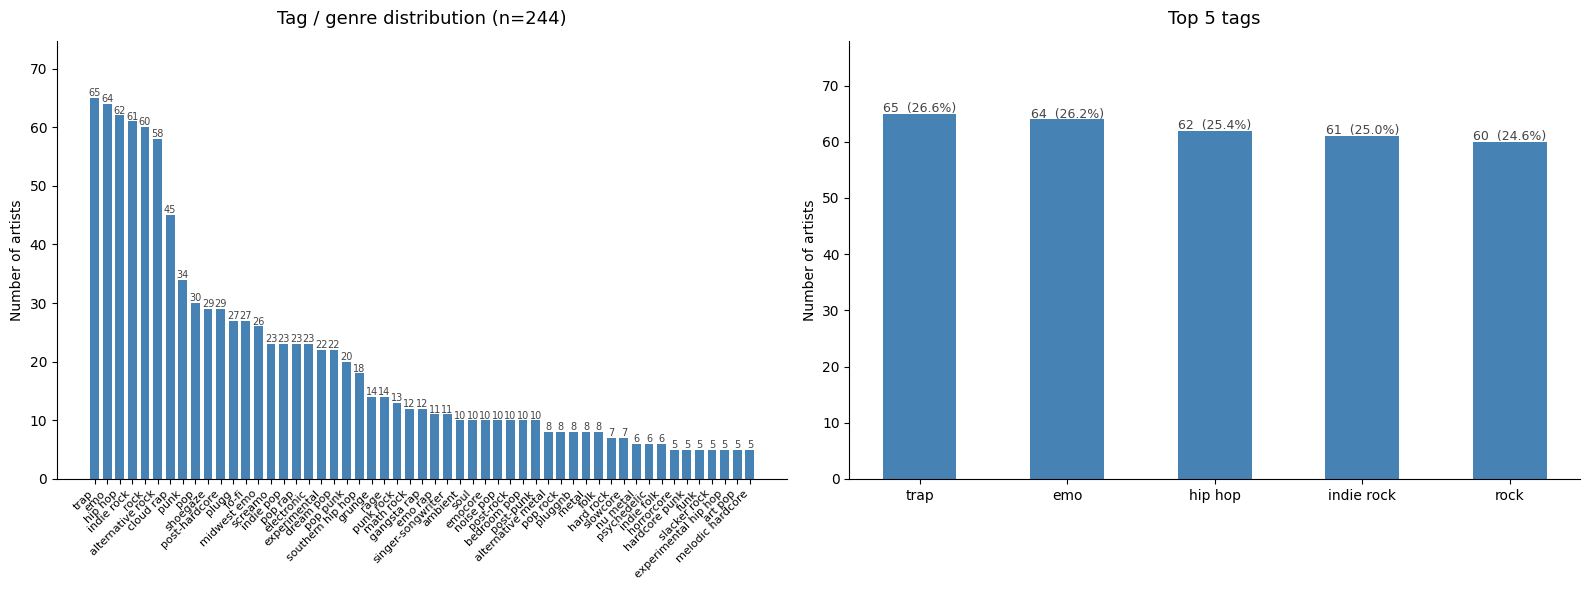

Top 5 exclusively indie rock artists by play count:
    artist_name  play_count
   wifiskeleton        1576
         Alex G        1245
Modern Baseball        1016
       Panchiko         799
       Marietta         712
Top 5 exclusively rock artists by play count:
                artist_name  play_count
                   Deftones        2715
                     Jaydes        2380
                    Nirvana        1630
        My Chemical Romance        1121
i wanna be a jack-o-lantern         561


In [36]:
tag_cols = final_df.columns.difference(['artist_name', 'play_count', 'url']).tolist()
tag_counts = final_df[tag_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# full distribution
bars = axes[0].bar(tag_counts.index, tag_counts.values, color='steelblue', edgecolor='none', width=0.7)
for bar, val in zip(bars, tag_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 str(val), ha='center', fontsize=7, color='#444')
axes[0].set_ylabel('Number of artists')
axes[0].set_title(f'Tag / genre distribution (n={len(final_df)})', fontsize=13, pad=12)
axes[0].set_xticks(range(len(tag_counts)))
axes[0].set_xticklabels(tag_counts.index, rotation=45, ha='right', fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim(0, tag_counts.max() * 1.15)

# top 5
top5 = tag_counts.head(5)
bars2 = axes[1].bar(top5.index, top5.values, color='steelblue', edgecolor='none', width=0.5)
for bar, val in zip(bars2, top5.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 f'{val}  ({val / len(final_df) * 100:.1f}%)',
                 ha='center', fontsize=9, color='#444')
axes[1].set_ylabel('Number of artists')
axes[1].set_title('Top 5 tags', fontsize=13, pad=12)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_ylim(0, top5.max() * 1.2)

plt.tight_layout()
plt.show()

# indie rock vs. rock genre
print('=' * 50)
print("Top 5 exclusively indie rock artists by play count:")
print(final_df[(final_df['indie rock'] == 1) & (final_df['rock'] == 0)].nlargest(5, 'play_count')[['artist_name', 'play_count']].to_string(index=False))

print('=' * 50)
print("Top 5 exclusively rock artists by play count:")
print(final_df[(final_df['rock'] == 1) & (final_df['indie rock'] == 0)].nlargest(5, 'play_count')[['artist_name', 'play_count']].to_string(index=False))

**Insights:**

- The genre distribution is heavily right skewed, with a set of 'broader' genres such as `trap`, `emo`, `hip hop`, `indie rock` and `rock` dominating.
- Genres such as `trap`, `emo`, and `indie rock` in LastFM aren't necessarily categorized as a more 'specific' genre / subgenre per se, nor are they necessarily part of any real hierarchy of genres or subgenres (i.e rock -> indie rock or hip hop -> trap).
    - In the case of `emo`, the genre has both been used to refer to both the original indie/punk subculture (Cap'n Jazz, Sunny Day Real Estate) and to the contemporary label applied to emotionally raw artists across hip hop, pop punk, and other genres (Lil Uzi Vert, Paramore, Panic! At The Disco).
    - Similarly, users most likely felt the `indie rock` tag to be a more apt description of artists that are closer both to independently produced music (Alex G, Panchiko) as well as the indie aesthetic (wifiskeleton) over the `rock` tag which usually implies mainstream acts such as Deftones, My Chemical Romance and Nirvana.
        - Worth noting is that the tags system is based on user-driven inputs, and then subsequently aggregated and weighted by how many users applied them.
        - As a result, tagging becomes inconsistent with heavy recency bias, prioritizing overall cultural consensus over accuracy (i.e Nirvana not being `indie rock` despite independent roots), and obscure artists resulting in a less reliable classified genre (i.e Jaydes and i wanna be a jack-o-lantern as `rock`).

## **Tag Count Per Artist**

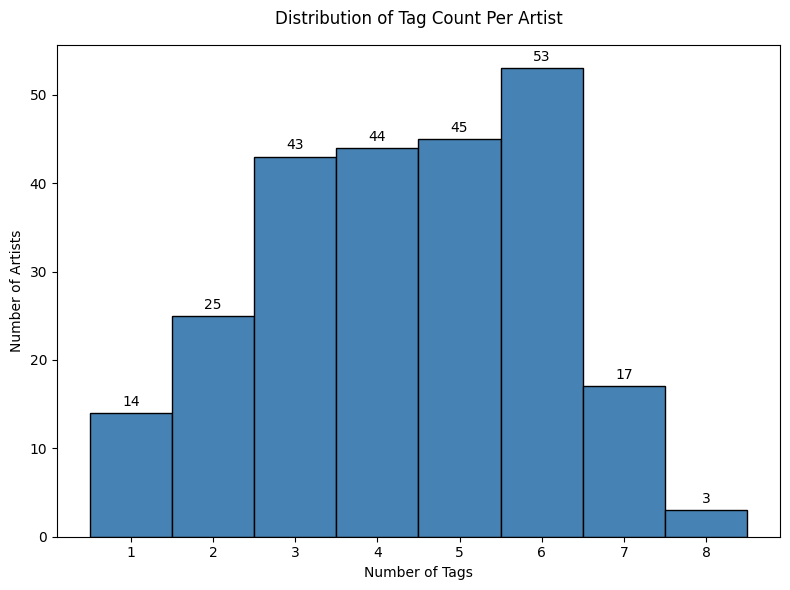

Mean Tag Count per Artist: 4.32
List of Artists with One Tag:
   artist_name        tags
Kendrick Lamar   [hip hop]
    Steve Lacy      [soul]
          Lamp [indie pop]
       MF DOOM   [hip hop]
       Fulcrum     [plugg]
      DECALIUS     [metal]
       Takeoff      [trap]
       J. Cole   [hip hop]
         Nunya      [punk]
      NewJeans       [pop]
   LE SSERAFIM       [pop]
   Joey Bada$$   [hip hop]
          imsg     [plugg]
         evvls       [emo]


In [39]:
tag_counts = artists_df['tags'].str.len()

fig, ax = plt.subplots(figsize=(8, 6))

# Define explicit integer bin edges from 1 to max+1
# This ensures each bar represents exactly ONE integer
bins = np.arange(1, max(tag_counts) + 2)

counts, edges, bars = ax.hist(tag_counts, bins=bins, color='steelblue', edgecolor='black', align='left')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Distribution of Tag Count Per Artist', pad=15)
ax.set_xlabel('Number of Tags')
ax.set_ylabel('Number of Artists')

# Explicitly set x-ticks to show every integer perfectly
ax.set_xticks(range(1, max(tag_counts) + 1))

plt.tight_layout()
plt.show()

print(f'Mean Tag Count per Artist: {tag_counts.mean().round(2)}')
# Check artists with one tag
artists_df['tag_count'] = artists_df['tags'].apply(len)

print('=' * 50, '\nList of Artists with One Tag:')
print(artists_df[artists_df['tag_count'] <= 1][['artist_name', 'tags']].to_string(index=False))

**Insights:**
- Based on the distribution, on average, each artist at least has 4.33 valid tags / genres applied to their LastFM artist page.
- 15 artists out of 247 (6%) have only one tag even after increasing tag limit to 15.
    - This is mainly due to removing sparse tags in the dataset which led these artists to only have one genre of which they represent the most.
    - Removing these artists may result in further data loss, so they stay as edge cases

## **Genre Correlation Heatmap**

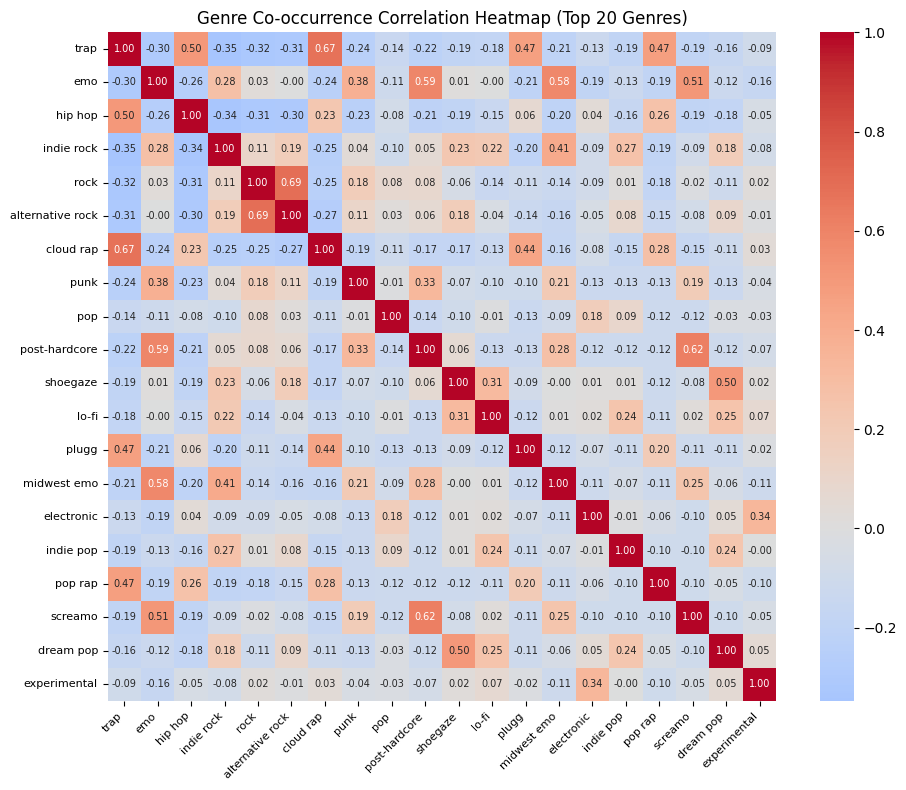

Strongest Correlations (co-occur frequently)
         genre_1       genre_2  correlation
alternative rock          rock     0.687237
       cloud rap          trap     0.669611
   post-hardcore       screamo     0.618338
             emo post-hardcore     0.587132
             emo   midwest emo     0.579168
             emo       screamo     0.509135
       dream pop      shoegaze     0.503415
         hip hop          trap     0.500080
         pop rap          trap     0.471893
           plugg          trap     0.467148
Weakest Correlations (rarely appear together)
         genre_1    genre_2  correlation
      indie rock       trap    -0.347912
         hip hop indie rock    -0.336976
            rock       trap    -0.322581
alternative rock       trap    -0.314723
         hip hop       rock    -0.311432
alternative rock    hip hop    -0.303810
             emo       trap    -0.296095
alternative rock  cloud rap    -0.265544
             emo    hip hop    -0.262424
       cloud ra

In [42]:
# get only the OHE columns
ohe_cols = mlb.classes_
ohe_df = final_df[ohe_cols]

# correlation matrix
top_genres = ohe_df.sum().nlargest(20).index
corr_matrix = ohe_df[top_genres].corr()

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 7},
    square=True
)
plt.title('Genre Co-occurrence Correlation Heatmap (Top 20 Genres)', fontsize=12)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# find strongly correlated genre pairs
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlation

# remove duplicates (A-B and B-A are the same pair)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

# reset index and rename columns
corr_pairs = corr_pairs.reset_index()
corr_pairs.columns = ['genre_1', 'genre_2', 'correlation']

strong_positive = corr_pairs[corr_pairs['correlation'] > 0.3].sort_values('correlation', ascending=False)
strong_negative = corr_pairs[corr_pairs['correlation'] < -0.1].sort_values('correlation')

print("=" * 50, "\nStrongest Correlations (co-occur frequently)")
print(strong_positive.head(10).to_string(index=False))

print("=" * 50, "\nWeakest Correlations (rarely appear together)")
print(strong_negative.head(10).to_string(index=False))

**Insights:**
- Based on the correlation heatmap matrix, the strongest correlations are the genres that both make sense sonically and are commonly paired together (`cloud rap` - `trap`, `emo` - `midwest emo`, `dream pop` - `shoegaze`).
- On the other hand, the weakest correlations are the genres that rarely appear together, whether it may be through it being a niche pairing or generally not making sense sonically (`indie rock` - `trap`, `rock` - `trap`, `cloud rap` - `indie rock`).

# **Data Modeling**

## **K-Means Clustering**

### **Feature Selection and Scaling**

#### **TF-IDF**

**Problem**: Artists are frequently tagged with broad genres such as `hip hop`, `rock`, `emo`, where it leads to these generalized broad genres simply just dominating everything telling us literally nothing about our actual music taste. Every artist becomes similar to each other simply because they have some combination of the same genres.

**Solution**: Utilize Term Frequency-Inverse Document Frequency (TF-IDF), penalizing tags that are broad and frequently appear everywhere by downweighting them and rewarding tags that are rarer and more specific. This makes it so that when we cluster, it's not necessarily just `hip hop` vs. `rock` vs. `emo`, it becomes more niche-driven and specific.

In [47]:
# Joins tags list into a single string per artist
tags_joined = artists_df['tags'].apply(
    lambda x: ' '.join([tag.replace('-', '_').replace(' ', '_') for tag in x]) 
    if isinstance(x, list) else ''
)

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(tags_joined)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray().round(3),
    columns=tfidf.get_feature_names_out(),
    index=[f'Doc{i+1}' for i in range(len(tags_joined))]
)

print(f"TF-IDF matrix shape: {tfidf_df.shape}")
print(f"Unique tags: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape: (244, 53)
Unique tags: 53


### **Find Optimal K**

#### **Elbow Analysis & Newton-Raphson**

In [50]:
K_range = range(1, 11)
wcss = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    km.fit(tfidf_matrix)
    wcss.append(km.inertia_)

# Discrete first and second differences
ks  = np.array(list(K_range), dtype=float)
ws  = np.array(wcss, dtype=float)
d1  = np.diff(ws)        # ΔInertia  ≈ f'(K)
d2  = np.diff(d1)        # ΔΔInertia ≈ f''(K)
ks2 = ks[1:-1]           # K values aligned with d2

# Print elbow table
print("--- Elbow Analysis ---")
print(f"{'K':<6}{'WCSS':<12}{'ΔInertia':>12}{'ΔΔInertia':>12}")
print("-" * 44)
for i, (k, w) in enumerate(zip(ks, ws)):
    d1_str = f"{d1[i-1]:>12.2f}" if i >= 1 else f"{'—':>12}"
    d2_str = f"{d2[i-2]:>12.2f}" if i >= 2 else f"{'—':>12}"
    print(f"  {int(k):<6}{w:<12.2f}{d1_str}{d2_str}")

# Fit quadratic to ΔΔInertia and run Newton-Raphson
coeffs = np.polyfit(ks2, d2, 2)
p      = np.poly1d(coeffs)
dp     = p.deriv()

print("\n--- Newton-Raphson Iterations (finding root of ΔΔInertia fit) ---")
print(f"{'n':<6}{'Kₙ':<12}{'p(Kₙ)':<14}{'p′(Kₙ)':<14}{'Kₙ₊₁':<12}{'|ΔK|'}")
print("-" * 62)

K = float(ks2.mean())
for i in range(50):
    pk    = p(K)
    dpk   = dp(K)
    if abs(dpk) < 1e-12:
        break
    K_new = K - pk / dpk
    delta = abs(K_new - K)
    print(f"  {i:<6}{K:<12.4f}{pk:<14.4f}{dpk:<14.4f}{K_new:<12.4f}{delta:.6f}")
    K = K_new
    if delta < 1e-6:
        break

optimal_k = int(round(np.clip(K, ks[0], ks[-1])))
print(f"\nNewton-Raphson converged at K* = {K:.4f}  →  Optimal K = {optimal_k}")

--- Elbow Analysis ---
K     WCSS            ΔInertia   ΔΔInertia
--------------------------------------------
  1     216.49                 —           —
  2     191.76            -24.74           —
  3     178.24            -13.52       11.22
  4     168.99             -9.26        4.26
  5     160.47             -8.52        0.73
  6     153.57             -6.90        1.63
  7     147.22             -6.35        0.54
  8     142.82             -4.40        1.96
  9     137.71             -5.11       -0.71
  10    132.06             -5.65       -0.54

--- Newton-Raphson Iterations (finding root of ΔΔInertia fit) ---
n     Kₙ          p(Kₙ)         p′(Kₙ)        Kₙ₊₁        |ΔK|
--------------------------------------------------------------
  0     5.5000      0.5301        -1.2459       5.9255      0.425469
  1     5.9255      0.0640        -0.9452       5.9932      0.067685
  2     5.9932      0.0016        -0.8973       5.9950      0.001804
  3     5.9950      0.0000        -0.89

Mathematical Elbow detected at K = 6


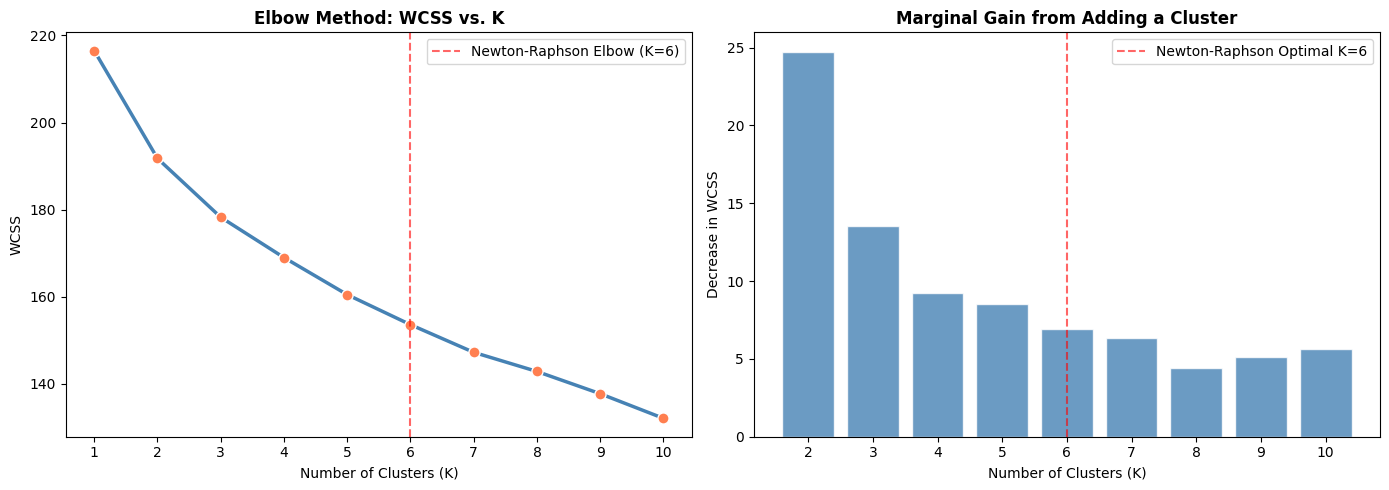

In [51]:
print(f"Mathematical Elbow detected at K = {optimal_k}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Elbow Curve ---
ax1.plot(list(K_range), wcss, marker='o', color='steelblue', linewidth=2.5,
         markersize=8, markerfacecolor='coral', markeredgecolor='white')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method: WCSS vs. K', fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6,
            label=f'Newton-Raphson Elbow (K={optimal_k})')
ax1.legend()

# --- Right Plot: Marginal Decrease ---
delta_wcss = [wcss[i-1] - wcss[i] for i in range(1, len(wcss))]
k_labels = list(range(2, len(list(K_range)) + 1))
ax2.bar(k_labels, delta_wcss, color='steelblue', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Decrease in WCSS')
ax2.set_title('Marginal Gain from Adding a Cluster', fontweight='bold')
ax2.set_xticks(k_labels)
ax2.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6,
            label=f'Newton-Raphson Optimal K={optimal_k}')
ax2.legend()

plt.tight_layout()
plt.show()

#### **Silhouette Scores in finding K**

Silhouette Analysis:
----------------------------------------
    K  |   Mean Silhouette Score
----------------------------------------
  K=2  |                  0.1129
  K=3  |                  0.1202
  K=4  |                  0.1270
  K=5  |                  0.1313
  K=6  |                  0.1217
  K=7  |                  0.1241
----------------------------------------


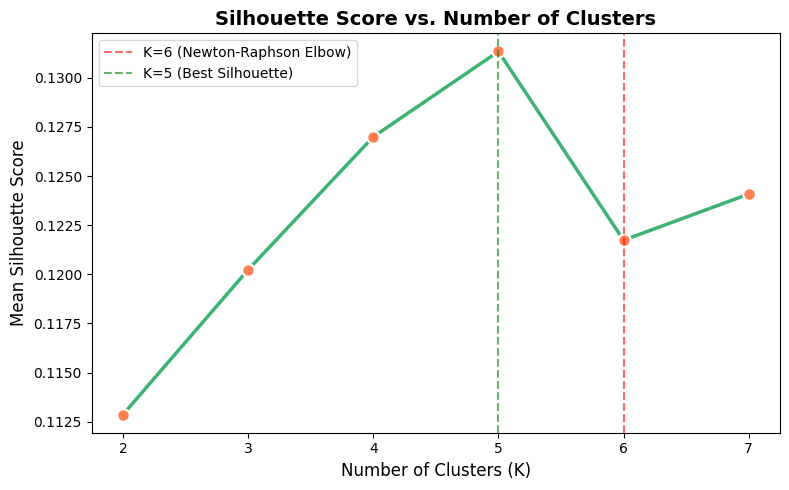


Best K by silhouette score: K=5 (score = 0.1313)


In [53]:
K_test = range(2, 8)
silhouette_scores = []

print("Silhouette Analysis:")
print("-" * 40)
print(f"{'K':>5}  |  {'Mean Silhouette Score':>22}")
print("-" * 40)

for k in K_test:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=300)
    labels = km.fit_predict(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, labels)
    silhouette_scores.append(score)
    print(f"  K={k}  |  {score:>22.4f}")

print("-" * 40)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(K_test), silhouette_scores, marker='o', color='mediumseagreen', linewidth=2.5,
         markersize=9, markerfacecolor='coral', markeredgecolor='white', markeredgewidth=1.5)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Mean Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs. Number of Clusters', fontsize=14, fontweight='bold')
plt.xticks(list(K_test))
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.6, 
            label=f'K={optimal_k} (Newton-Raphson Elbow)')
best_k = list(K_test)[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.6, 
            label=f'K={best_k} (Best Silhouette)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette score: K={best_k} (score = {max(silhouette_scores):.4f})")

optimal_k = 5

**Insights:**

- Moving forward, I will be utilizing K=5. This is due to silhouette score rapidly dropping at K=6, while it is at its highest at K=5
- The $\small{\triangle \triangle}$Inertia is at its lowest at K=5 compared to K=6 where it actually rose.
- Looking closer at Newton-Raphson method, K converged at 5.63 but rounded up to 6, which means it's closer to K=5 than it appears.

### **Silhouette Plot Comparison**

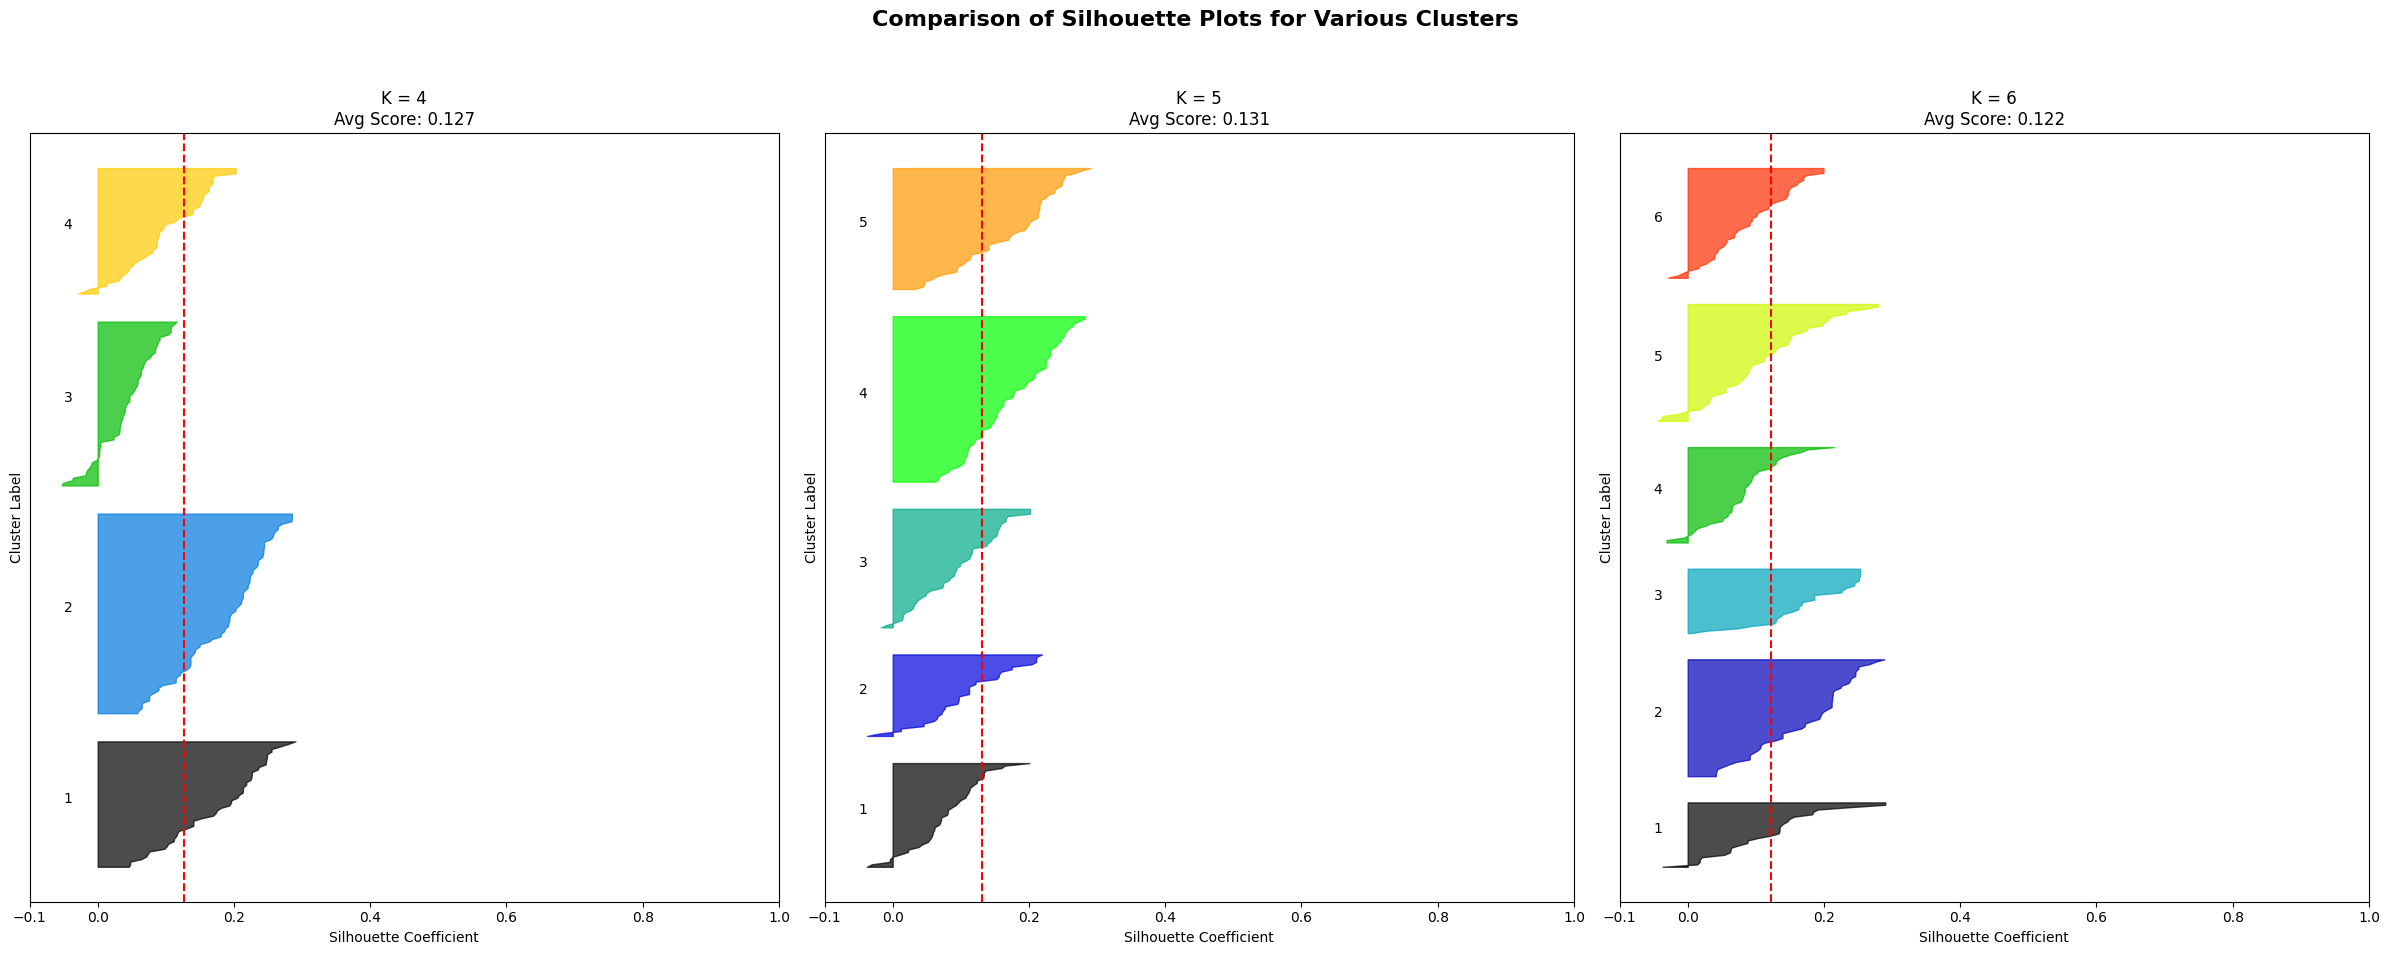

In [56]:
# Compare K values around our optimal
range_n_clusters = [4, 5, 6]

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42, max_iter=300)
labels_final = km_final.fit_predict(tfidf_matrix)

# Create a figure with subplots (1 row, multiple columns)
fig, axes = plt.subplots(1, len(range_n_clusters), figsize=(24, 10))

for idx, n_clusters in enumerate(range_n_clusters):
    ax = axes[idx]
    
    # Initialize and fit KMeans
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(tfidf_matrix)
    
    # Calculate scores
    silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    sample_silhouette_values = silhouette_samples(tfidf_matrix, cluster_labels)
    
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i + 1))
        y_lower = y_upper + 10

    ax.set_title(f"K = {n_clusters}\nAvg Score: {silhouette_avg:.3f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle("Comparison of Silhouette Plots for Various Clusters", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insights:**

- Looking at each silhouette plot, the clear-cut best K would still be ``K=5``
- While ``K=4`` has the least amount of clusters, both gray and blue clusters dominate and are too wide leading to the yellow cluster falling short.
- ``K=5`` has the most even and balanced distribution out of all three plots. Clusters 2-4 are relatively even, where all clusters are past the average line.
- For ``K=6``, the clusters are too fragmented, suggesting that it leads to over-splitting of coherent genre groups.

### **Fit Final K-means Model**

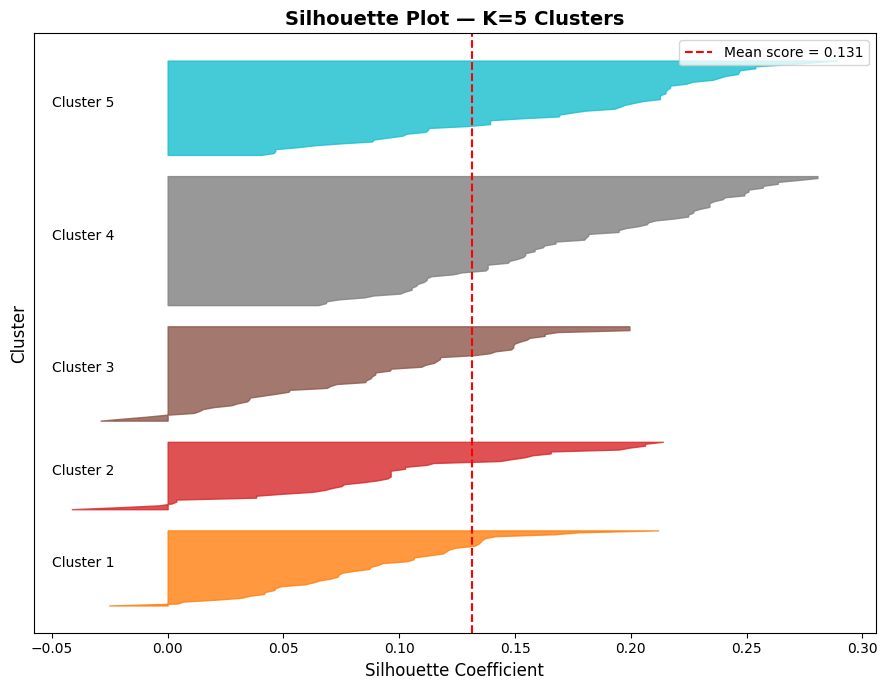

Silhouette Score: 0.1313
Davies-Bouldin Index: 2.5077
Calinski-Harabasz Index: 20.8463


In [59]:
K_final = 5
km_final = KMeans(n_clusters=K_final, init='k-means++', n_init=10, random_state=42, max_iter=300)
labels_final = km_final.fit_predict(tfidf_df)

silhouette_vals = silhouette_samples(tfidf_df, labels_final)
avg_score = silhouette_score(tfidf_df, labels_final)

s_score_k = silhouette_score(tfidf_df, labels_final)
db_index_k = davies_bouldin_score(tfidf_df, labels_final)
ch_index_k = calinski_harabasz_score(tfidf_df, labels_final)

fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10
colors = cm.tab10(np.linspace(0.1, 0.9, K_final))

for i in range(K_final):
    cluster_sil_vals = silhouette_vals[labels_final == i]
    cluster_sil_vals.sort()
    cluster_size = len(cluster_sil_vals)
    y_upper = y_lower + cluster_size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, f'Cluster {i+1}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean score = {avg_score:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot — K={K_final} Clusters', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Silhouette Score: {s_score_k:.4f}")
print(f"Davies-Bouldin Index: {db_index_k:.4f}")
print(f"Calinski-Harabasz Index: {ch_index_k:.4f}")

**Insights:**

### **Dimensionality Reduction**
- **Problem:** Since our TF-IDF dataframe contains 57 columns / dimensions, I'll need to be able to project the high-dimensionality of each genre to a 2-dimensional space in order to fully prepare, capture and visualize the clusters without removing any features.
- **Solution:** Utilize PCA & UMAP as dimensionality reduction methods in order to properly visualize the clustering of K-Means

#### **PCA**

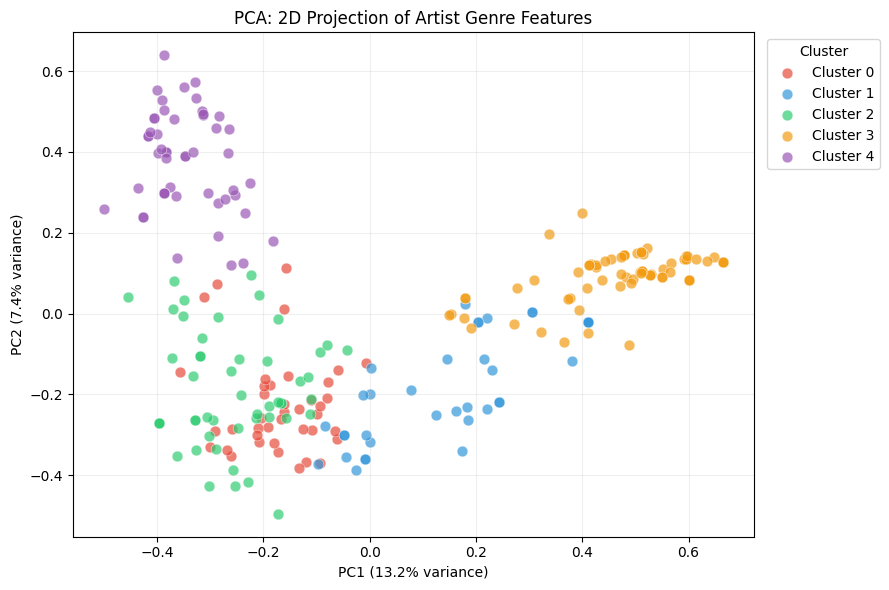

PCA 2D PROJECTION SUMMARY
  PC1 explains: 13.24% of variance
  PC2 explains: 7.37% of variance
  Combined:     20.61%

Top 5 genres contributing most to PC1 (by absolute loading):
  +0.447  trap
  +0.432  hip_hop
  +0.321  cloud_rap
  -0.246  emo
  -0.243  indie_rock

Top 5 genres contributing most to PC2 (by absolute loading):
  +0.436  emo
  +0.316  midwest_emo
  +0.301  screamo
  +0.285  post_hardcore
  -0.262  pop



In [63]:
# Project onto first two PCs (visualization)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(tfidf_df)

# Project onto first ten PCs (downstream use e.g. UMAP, KMeans input)
pca_10 = PCA(n_components=10, random_state=42)
X_pca_10 = pca_10.fit_transform(tfidf_df)

# Extract cluster labels from fitted KMeans model
cluster_labels = km_final.labels_

assert len(cluster_labels) == len(tfidf_df), (
    f"Mismatch: cluster_labels has {len(cluster_labels)} labels, tfidf_df has {len(tfidf_df)} rows"
)

n_clusters = len(np.unique(cluster_labels))
colors = {
    0: '#e74c3c',  # red
    1: '#3498db',  # blue
    2: '#2ecc71',  # green
    3: '#f39c12',  # orange
    4: '#9b59b6',  # purple
}
# 2D scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

for cls in range(n_clusters):
    mask = (cluster_labels == cls)  # fixed — was km_final == cls
    ax.scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        color=colors[cls], label=f'Cluster {cls}',
        alpha=0.7, s=60, edgecolors='white', linewidths=0.4
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA: 2D Projection of Artist Genre Features')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Summary
print("=" * 70)
print("PCA 2D PROJECTION SUMMARY")
print("=" * 70)
print(f"  PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"  PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"  Combined:     {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print()

# Top contributing genres per PC
genre_cols = tfidf_df.columns.tolist()
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=genre_cols,
    columns=['PC1', 'PC2']
)

for pc in ['PC1', 'PC2']:
    print(f"Top 5 genres contributing most to {pc} (by absolute loading):")
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    for genre, val in top.items():
        direction = "+" if loadings.loc[genre, pc] > 0 else "-"
        print(f"  {direction}{abs(val):.3f}  {genre}")
    print()

#### **UMAP**

UMAP: EXPLORING n_neighbors SENSITIVITY

UMAP key parameters:
  n_neighbors: local vs global tradeoff (5 = local, 50 = global)
  min_dist:    how tightly to pack points in 2D
  random_state: always set

  Fitting UMAP with n_neighbors=5... done
  Fitting UMAP with n_neighbors=15... done
  Fitting UMAP with n_neighbors=50... done


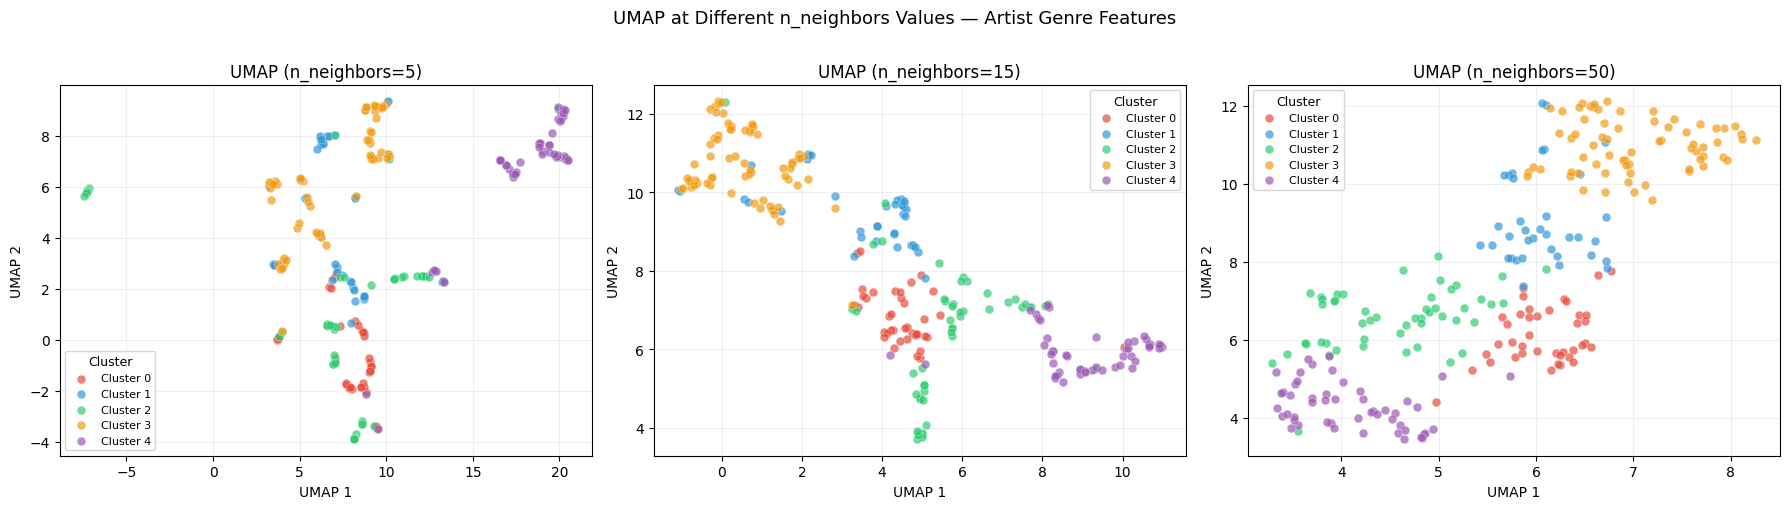


Observations:
  • Small n_neighbors (5):  fragmented, emphasis on local genre structure.
  • n_neighbors=15:         good balance, preserves local and global.
  • Large n_neighbors (50): smoother, global genre structure emphasized.

UMAP vs PCA on this dataset:
  • PCA (20.4% variance): linear projection, loses non-linear structure.
  • UMAP: captures non-linear genre relationships PCA cannot show.
  • UMAP can embed new artists at inference time; t-SNE cannot.


In [65]:
if UMAP_AVAILABLE:
    print("=" * 70)
    print("UMAP: EXPLORING n_neighbors SENSITIVITY")
    print("=" * 70)
    print()
    print("UMAP key parameters:")
    print("  n_neighbors: local vs global tradeoff (5 = local, 50 = global)")
    print("  min_dist:    how tightly to pack points in 2D")
    print("  random_state: always set")
    print()

    neighbor_values = [5, 15, 50]
    umap_results = {}

    for n in neighbor_values:
        print(f"  Fitting UMAP with n_neighbors={n}...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=n,
                            min_dist=0.1, random_state=42)
        umap_results[n] = reducer.fit_transform(tfidf_df)
        print("done")

    # Plot all three n_neighbors values
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, n in zip(axes, neighbor_values):
        Z = umap_results[n]
        for cls in range(n_clusters):
            mask = (cluster_labels == cls)
            ax.scatter(
                Z[mask, 0], Z[mask, 1],
                color=colors[cls], label=f'Cluster {cls}',
                alpha=0.7, s=40, edgecolors='white', linewidths=0.3
            )
        ax.set_title(f'UMAP (n_neighbors={n})')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.legend(title='Cluster', fontsize=8, title_fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.suptitle('UMAP at Different n_neighbors Values — Artist Genre Features',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print()
    print("Observations:")
    print("  • Small n_neighbors (5):  fragmented, emphasis on local genre structure.")
    print("  • n_neighbors=15:         good balance, preserves local and global.")
    print("  • Large n_neighbors (50): smoother, global genre structure emphasized.")
    print()
    print("UMAP vs PCA on this dataset:")
    print("  • PCA (20.4% variance): linear projection, loses non-linear structure.")
    print("  • UMAP: captures non-linear genre relationships PCA cannot show.")
    print("  • UMAP can embed new artists at inference time; t-SNE cannot.")

else:
    print("UMAP not available. Install with: pip install umap-learn")
    print("Skipping UMAP section.")

**Insights:**
- Utilize ``n_neighbors=15``

#### **Genre Cluster Labels**

In [66]:
# Align indices before attaching cluster labels
artists_df = artists_df.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

# Attach cluster labels to your artist dataframe
artists_df['cluster'] = cluster_labels

# For each cluster: show artists and their top genres
for cls in range(n_clusters):
    subset = artists_df[artists_df['cluster'] == cls]
    print(f"{'=' * 70}")
    print(f"CLUSTER {cls}  ({len(subset)} artists)")
    print(f"{'=' * 70}")
    
    # Artists in this cluster
    print(subset[['artist_name', 'play_count']].sort_values('play_count', ascending=False).to_string(index=False))
    print()
    
    # Dominant genres (mean TF-IDF weight across cluster)
    genre_means = tfidf_df.loc[subset.index].mean().sort_values(ascending=False)
    print("Top genres:")
    print(genre_means.head(8).to_string())
    print()

CLUSTER 0  (40 artists)
                     artist_name  play_count
                         TV Girl        1298
                          Alex G        1245
                        Panchiko         799
             my bloody valentine         669
                          Clairo         651
                     Mac DeMarco         552
                            Cuco         496
                      Weatherday         474
                           Whirr         414
                            Lamp         401
                          Duster         385
                     beabadoobee         363
                   Megumi Acorda         363
                  Lily Chou-Chou         336
                     Summer 2000         329
               Car Seat Headrest         319
                        Slowdive         312
                Have a Nice Life         289
              Neutral Milk Hotel         261
              Jonatan Leandoer96         240
                   Elliott Smit

**Insights:**

- There are a few outliers based on the limitations of LastFM tags / genres, notably artists such as Alex G, Elliott Smith, Mac DeMarco and others being categorized as ``dream pop / shoegaze`` when they fit more into the indie rock genre.
    - Outsmarting Simon, They Are Gutting a Body of Water are artists also more akin to emo rather than either genres
- ``Trap / cloud rap`` managed to remarkably be correct all around, was able to properly describe most if not all artists in this cluster as trap
    - There is some overlap with the hip hop cluster overall 
- ``Rock / alt rock`` managed to mostly be correct in clustering, as most artists here are mainstream artists aside from a few outliers like Ozma, i wanna be a jack-o-lantern, Fried by Fluoride, Joyce Manor, etc.
- ``Emo / midwest emo``
- ``Hip hop / pop``


### **Final K-Means Clustering Plot**

Generated cluster names:
  Cluster 0: Dream Pop / Lo Fi
  Cluster 1: Hip Hop / Pop
  Cluster 2: Alternative Rock / Rock
  Cluster 3: Trap / Cloud Rap
  Cluster 4: Emo / Midwest Emo

Fitting UMAP...
Done.


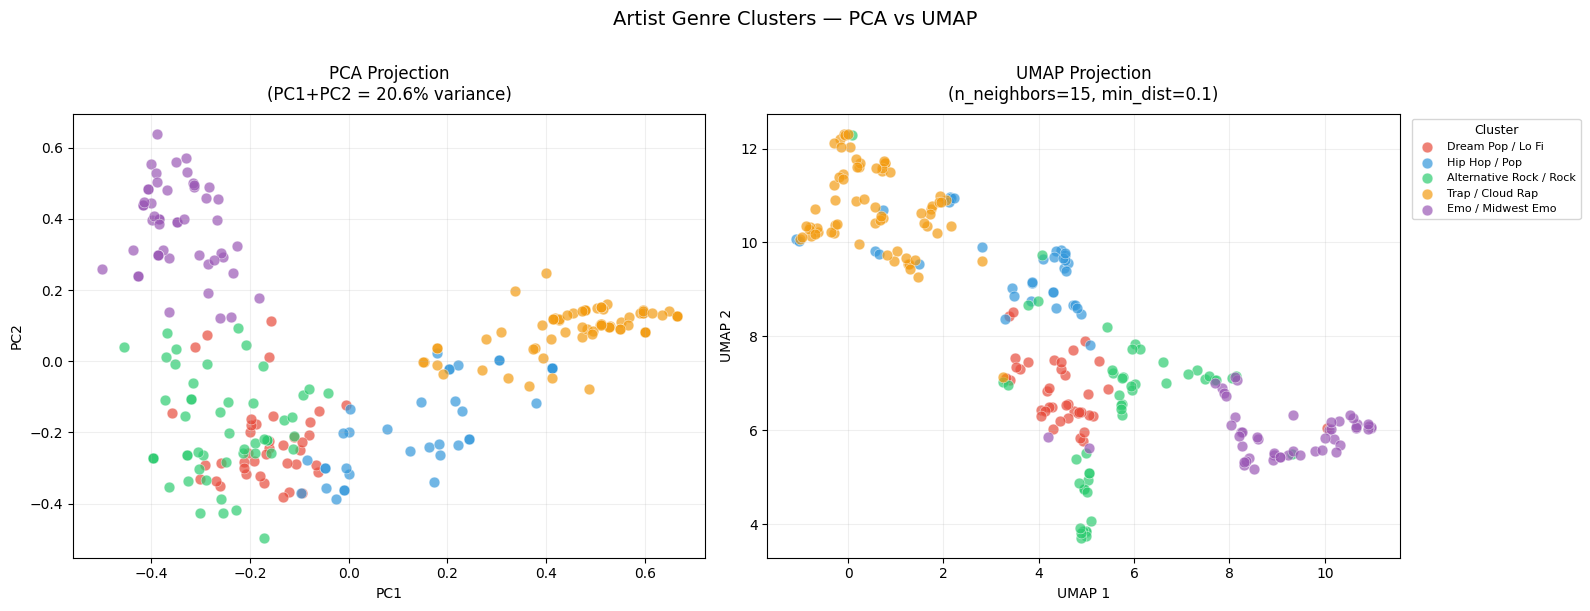

In [69]:
# Auto-name clusters from top 2 genres
cluster_names = {}
for cls in range(n_clusters):
    subset_idx = artists_df[artists_df['cluster'] == cls].index
    genre_means = tfidf_df.loc[subset_idx].mean().sort_values(ascending=False)
    top2 = genre_means.head(2).index.tolist()
    cluster_names[cls] = ' / '.join(g.replace('_', ' ').title() for g in top2)

print("Generated cluster names:")
for cls, name in cluster_names.items():
    print(f"  Cluster {cls}: {name}")

# Fit UMAP for final visualization
print("\nFitting UMAP...")
reducer_final = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_final = reducer_final.fit_transform(tfidf_df)
print("Done.")

# PCA vs UMAP side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

datasets = [
    (X_pca_2d, f'PCA Projection\n(PC1+PC2 = {sum(pca_2d.explained_variance_ratio_)*100:.1f}% variance)'),
    (X_umap_final, 'UMAP Projection\n(n_neighbors=15, min_dist=0.1)'),
]

for ax, (X_proj, title) in zip(axes, datasets):
    for cls in range(n_clusters):
        mask = (cluster_labels == cls)
        ax.scatter(
            X_proj[mask, 0], X_proj[mask, 1],
            color=colors[cls],
            label=cluster_names[cls],
            alpha=0.7, s=60,
            edgecolors='white', linewidths=0.4
        )
    ax.set_title(title, fontsize=12, pad=10)
    ax.grid(True, alpha=0.2)

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

# Single legend on the right plot only
axes[1].legend(
    title='Cluster', fontsize=8, title_fontsize=9,
    bbox_to_anchor=(1.01, 1), loc='upper left'
)

plt.suptitle('Artist Genre Clusters — PCA vs UMAP', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insights:**

## **DBScan Clustering**
- Use ``cosine`` distance over ``euclidean`` 
- Normalize ``tfidf_df`` since artists with many tags has a long vector while other artists with few tags has a short vector
    - Without normalizing, each artist vector would have a different magnitude
    - Cosine distance will **only** measure the angle between two artists rather than the amount of tags they have

### **Normalize TF-IDF**

In [72]:
tfidf_normalized = normalize(tfidf_df, norm='l2')
print(tfidf_normalized)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.34407037]
 [0.         0.         0.         ... 0.         0.         0.3549842 ]
 ...
 [0.         0.         0.         ... 0.         0.         0.70007141]
 [0.         0.32802936 0.         ... 0.         0.         0.        ]
 [0.52699473 0.         0.         ... 0.         0.         0.        ]]


### **Find optimal eps value**

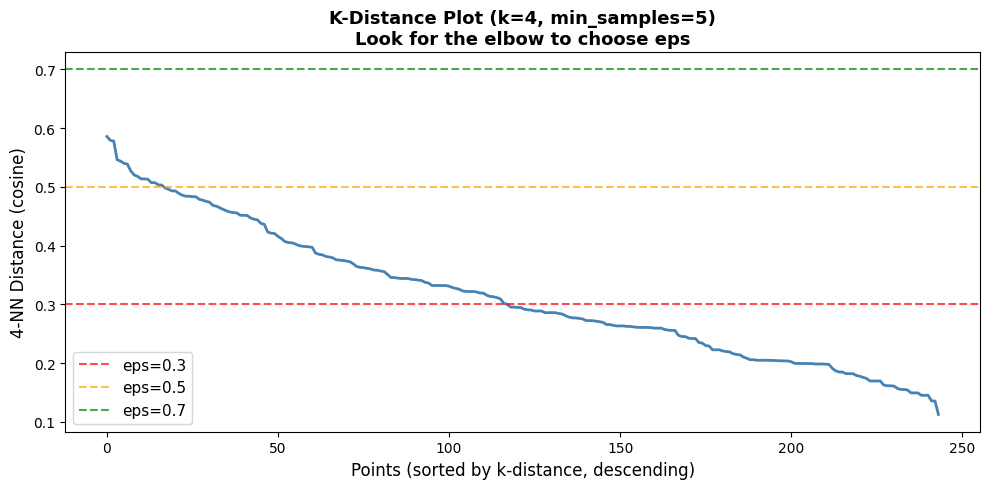

Reading the plot:
  The 'elbow' is where the curve bends sharply.
  Setting eps at the elbow separates dense (cluster) points from sparse (noise) points.


In [74]:
min_samples = 5
k = min_samples - 1  # k-distance uses k = min_samples - 1

# Fit nearest neighbors on normalized TF-IDF matrix
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(tfidf_normalized)  # +1 because point counts itself
distances, _ = nbrs.kneighbors(tfidf_normalized)

# Get the k-th neighbor distance for each point (last column)
k_distances = np.sort(distances[:, -1])[::-1]  # sort descending

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(k_distances)), k_distances, color='steelblue', linewidth=2)
ax.set_xlabel('Points (sorted by k-distance, descending)', fontsize=12)
ax.set_ylabel(f'{k}-NN Distance (cosine)', fontsize=12)
ax.set_title(f'K-Distance Plot (k={k}, min_samples={min_samples})\nLook for the elbow to choose eps',
             fontsize=13, fontweight='bold')

# Annotate candidate eps values
for eps_candidate, color, label in [(0.3, 'red', 'eps=0.3'), (0.5, 'orange', 'eps=0.5'), (0.7, 'green', 'eps=0.7')]:
    ax.axhline(y=eps_candidate, color=color, linestyle='--', alpha=0.7, label=label)

ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Reading the plot:")
print("  The 'elbow' is where the curve bends sharply.")
print("  Setting eps at the elbow separates dense (cluster) points from sparse (noise) points.")

**Insights:**
- Observing the K-Distance plot, the eps values with the most 'visible' curve is 0.5, 0.3, and 0.2
    - It should be noted that the the line / curve of each eps value is very subtle, it is probably best to observe the silhouette score of each eps value

In [76]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
results = []
print(f"{'eps':>6}  |  {'Clusters':>9}  |  {'Noise pts':>10}  |  {'Noise %':>8}  |  {'Silhouette':>12}")
print("-" * 60)
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine').fit(tfidf_normalized)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100

    if n_clusters >= 2:
        # Silhouette only on non-noise points
        mask = labels != -1
        sil = silhouette_score(tfidf_normalized[mask], labels[mask], metric='cosine') if mask.sum() > 1 else float('nan')
    else:
        sil = float('nan')

    results.append({'eps': eps, 'n_clusters': n_clusters, 'n_noise': n_noise,
                    'noise_pct': noise_pct, 'silhouette': sil, 'labels': labels})

    sil_str = f"{sil:.4f}" if not np.isnan(sil) else "  N/A"
    print(f"  {eps:>4}  |  {n_clusters:>9}  |  {n_noise:>10}  |  {noise_pct:>7.1f}%  |  {sil_str:>12}")

print()
print("Observations:")
print("  Compare cluster count, noise %, and silhouette across eps values")
print("  to identify the most balanced configuration.")

   eps  |   Clusters  |   Noise pts  |   Noise %  |    Silhouette
------------------------------------------------------------
   0.2  |          9  |         160  |     65.6%  |        0.4972
   0.3  |          7  |          76  |     31.1%  |        0.2940
   0.4  |          2  |          22  |      9.0%  |        0.0979
   0.5  |          1  |           0  |      0.0%  |           N/A
   0.6  |          1  |           0  |      0.0%  |           N/A

Observations:
  Compare cluster count, noise %, and silhouette across eps values
  to identify the most balanced configuration.


**Insights:**
- Between all eps values, the best eps would have to be ``eps = 0.3``.
- I decided this mainly due to its silhouette score. ``eps = 0.2`` has too many clusters and noise %.
- ``eps = 0.4`` has too few clusters with the lowest silhouette value out of all eps values tested.

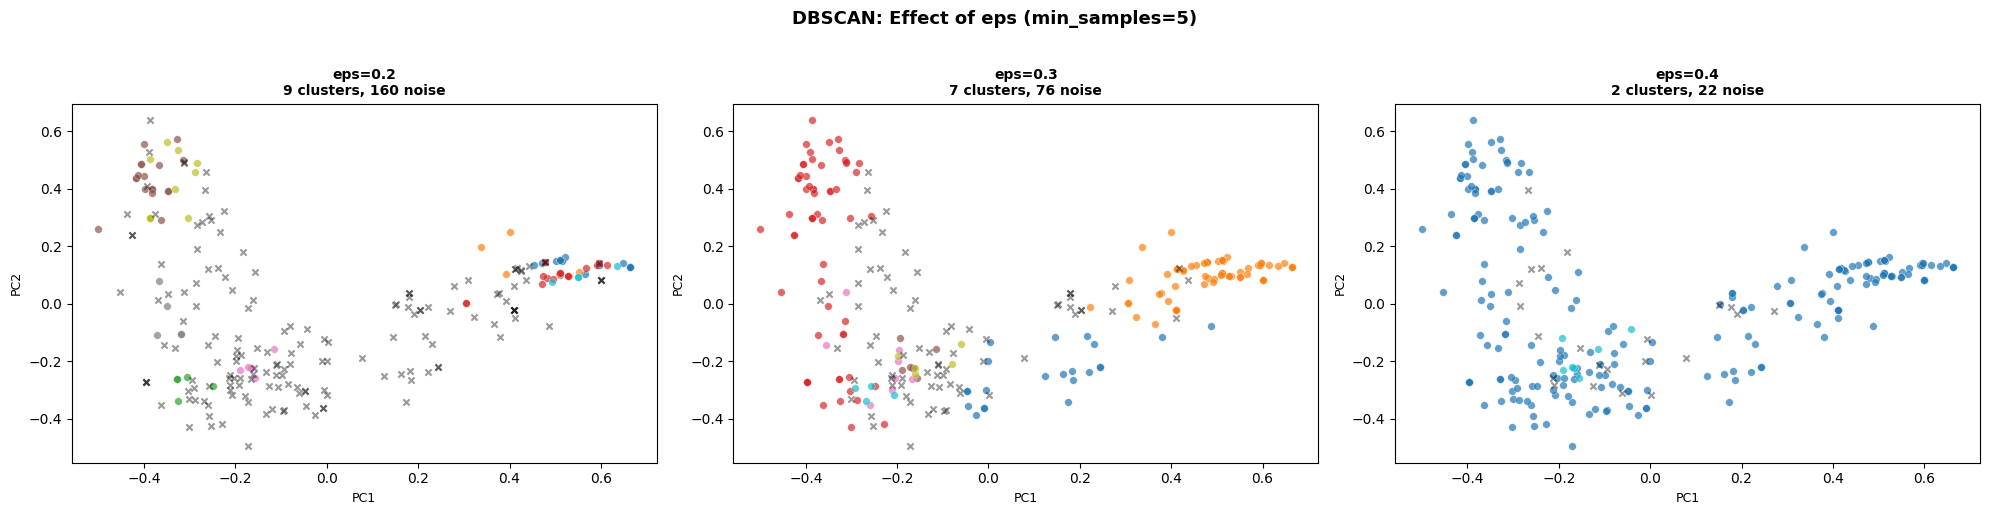

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors_map = plt.cm.tab10

for ax, res in zip(axes, results):
    labels = res['labels']
    unique_labels = set(labels)

    for label in unique_labels:
        mask = labels == label
        if label == -1:
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c='black', s=20, alpha=0.4,
                       marker='x', label='Noise')
        else:
            color = colors_map(label / max(max(labels), 1))
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], color=color, s=30, alpha=0.7,
                       edgecolors='white', linewidth=0.3)

    n_c = res['n_clusters']
    n_n = res['n_noise']
    ax.set_title(f"eps={res['eps']}\n{n_c} clusters, {n_n} noise", fontsize=10, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)

plt.suptitle('DBSCAN: Effect of eps (min_samples=5)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insights:**

- Proceed with ``eps = 0.3`` as it has the best balance of noise % while still maintaining a semblance of structure.

#### **Genre Cluster Labels**

In [103]:
for lbl in sorted(set(labels)):
    subset = artists_df[artists_df['DBSCAN_Cluster'] == lbl]
    name = f"CLUSTER {lbl}" if lbl != -1 else "NOISE (-1)"

    print(f"{'=' * 70}")
    print(f"{name}  ({len(subset)} artists)")
    print(f"{'=' * 70}")

    for idx, row in subset.sort_values('play_count', ascending=False).iterrows():
        tags = row['tags'] if isinstance(row['tags'], list) else []
        print(f"{row['artist_name']:<30} {row['play_count']:>6}  |  {', '.join(tags)}")

    print()

    if lbl != -1:
        genre_means = tfidf_df.loc[subset.index].mean().sort_values(ascending=False)
        print("Top genres:")
        print(genre_means.head(8).to_string())
    print()

NOISE (-1)  (76 artists)
Title Fight                      2788  |  melodic hardcore, pop punk, punk, punk rock, emo, post-hardcore, shoegaze, hardcore punk
Jaydes                           2380  |  pluggnb, experimental, punk, rock, alternative rock, plugg
Tyler, The Creator               2313  |  hip hop, horrorcore
Radiohead                        2241  |  rock, alternative rock, electronic, experimental, indie rock
Young Thug                       1672  |  trap, hip hop, horrorcore, pop rap, southern hip hop
Nirvana                          1630  |  grunge, rock, alternative rock, punk, hard rock
wifiskeleton                     1576  |  emo, indie rock, slacker rock
TV Girl                          1298  |  indie pop, lo-fi, pop
Ecco2K                            793  |  cloud rap, art pop, emo rap
widowdusk                         705  |  screamo, emo, lo-fi
my bloody valentine               669  |  shoegaze, dream pop, indie rock, noise pop, alternative rock, rock, post-punk
The S

**Insights:**

- DBScan has a much more concrete definition of each genre, being conservative with what genres certain artists belong to, while on the other hand K-Means forces each artist into a specifically defined genre of cluster.
- The use of noise *can* be useful in some scenarios where certain artists can be categorized as genre ambiguous (in-between multiple tags / genres that are rarely seen together) or don't really fit anywhere within the defined MusicBrainz genre list.
    - Artists that are classified as noise either have a low amount of tags / genres, or have a unique set of tags that further differentiate them from similar artists
- This resulted in ~30% of artists (76 artists out of 247) to not fully be categorized in a defined cluster.
- Further observation of the noise cluster based on the plot are that they are points that are similar to genre-defined clusters, but are too far away or too distinct from core points of the cluster.

### **Final DBScan Clustering Plot**

DBSCAN cluster names:
  Cluster -1: Noise
  Cluster 0: Electronic / Pop
  Cluster 1: Trap / Hip Hop
  Cluster 2: Emo / Indie Rock
  Cluster 3: Alternative Metal / Metal
  Cluster 4: Slowcore / Lo Fi
  Cluster 5: Indie Folk / Folk
  Cluster 6: Dream Pop / Shoegaze

Final DBSCAN (eps=0.3, min_samples=5)
  Clusters found  : 7
  Noise points    : 76 (31.1%)

Cluster sizes:
                                     Noise: 76 points (31.1%)
                          Electronic / Pop: 22 points (9.0%)
                            Trap / Hip Hop: 63 points (25.8%)
                          Emo / Indie Rock: 59 points (24.2%)
                 Alternative Metal / Metal: 7 points (2.9%)
                          Slowcore / Lo Fi: 8 points (3.3%)
                         Indie Folk / Folk: 5 points (2.0%)
                      Dream Pop / Shoegaze: 4 points (1.6%)


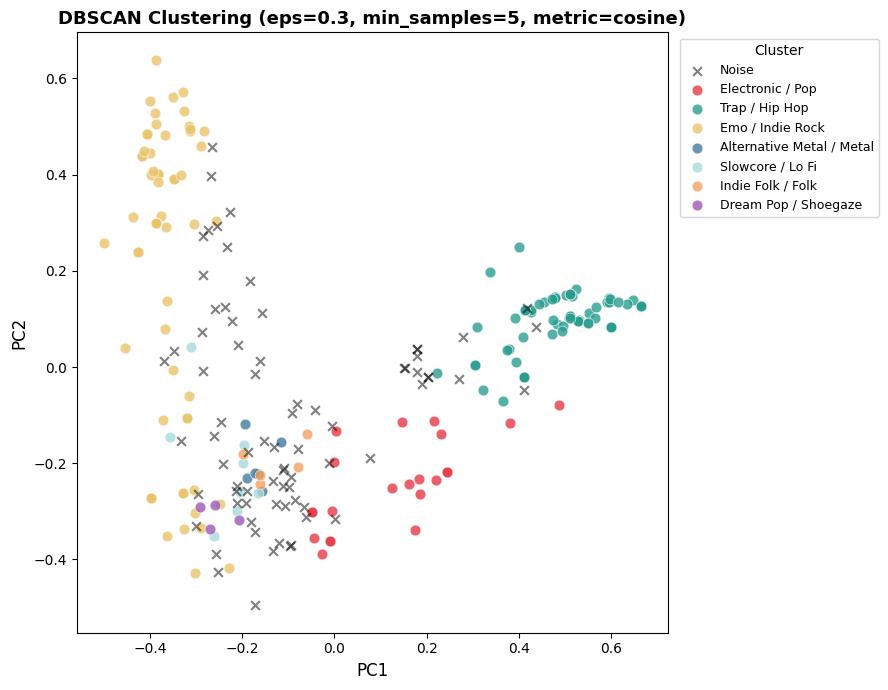

In [113]:
eps_final = 0.3
db_final = DBSCAN(eps=eps_final, min_samples=min_samples, metric='cosine').fit(tfidf_normalized)
artists_df['DBSCAN_Cluster'] = db_final.labels_
labels = db_final.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

# Auto-name DBSCAN clusters from top 2 genres
dbscan_cluster_names = {-1: 'Noise'}
for lbl in sorted(set(labels)):
    if lbl == -1:
        continue
    subset_idx = artists_df[artists_df['DBSCAN_Cluster'] == lbl].index
    genre_means = tfidf_df.loc[subset_idx].mean().sort_values(ascending=False)
    top2 = genre_means.head(2).index.tolist()
    dbscan_cluster_names[lbl] = ' / '.join(g.replace('_', ' ').title() for g in top2)

print("DBSCAN cluster names:")
for lbl, name in dbscan_cluster_names.items():
    print(f"  Cluster {lbl}: {name}")

print(f"\nFinal DBSCAN (eps={eps_final}, min_samples={min_samples})")
print(f"  Clusters found  : {n_clusters}")
print(f"  Noise points    : {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print()
print("Cluster sizes:")
for lbl in sorted(set(labels)):
    count = (labels == lbl).sum()
    name = dbscan_cluster_names[lbl]
    print(f"  {name:>40}: {count} points ({count/len(labels)*100:.1f}%)")

# Visualization
dbscan_palette = {
    -1: 'black',
    0: '#e63946',
    1: '#2a9d8f',
    2: '#e9c46a',
    3: '#457b9d',
    4: '#a8dadc',
    5: '#f4a261',
    6: '#9b59b6'
}

fig, ax = plt.subplots(figsize=(9, 7))

for lbl in sorted(set(labels)):
    mask = labels == lbl
    if lbl == -1:
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c='black', s=40, alpha=0.5,
                   marker='x', zorder=5, label=dbscan_cluster_names[-1])
    else:
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], color=dbscan_palette[lbl],
                   s=60, alpha=0.8, edgecolors='white', linewidth=0.5,
                   label=dbscan_cluster_names[lbl])

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(f'DBSCAN Clustering (eps={eps_final}, min_samples={min_samples}, metric=cosine)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, title='Cluster', title_fontsize=10,
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **DB-Scan vs. K-Means (PCA and UMAP)**

DBSCAN cluster names:
  Cluster -1: Noise
  Cluster 0: Electronic / Pop
  Cluster 1: Trap / Hip Hop
  Cluster 2: Emo / Indie Rock
  Cluster 3: Alternative Metal / Metal
  Cluster 4: Slowcore / Lo Fi
  Cluster 5: Indie Folk / Folk
  Cluster 6: Dream Pop / Shoegaze
KMeans cluster names:
  Cluster 0: Dream Pop / Lo Fi
  Cluster 1: Hip Hop / Pop
  Cluster 2: Alternative Rock / Rock
  Cluster 3: Trap / Cloud Rap
  Cluster 4: Emo / Midwest Emo

Fitting UMAP...
Done.


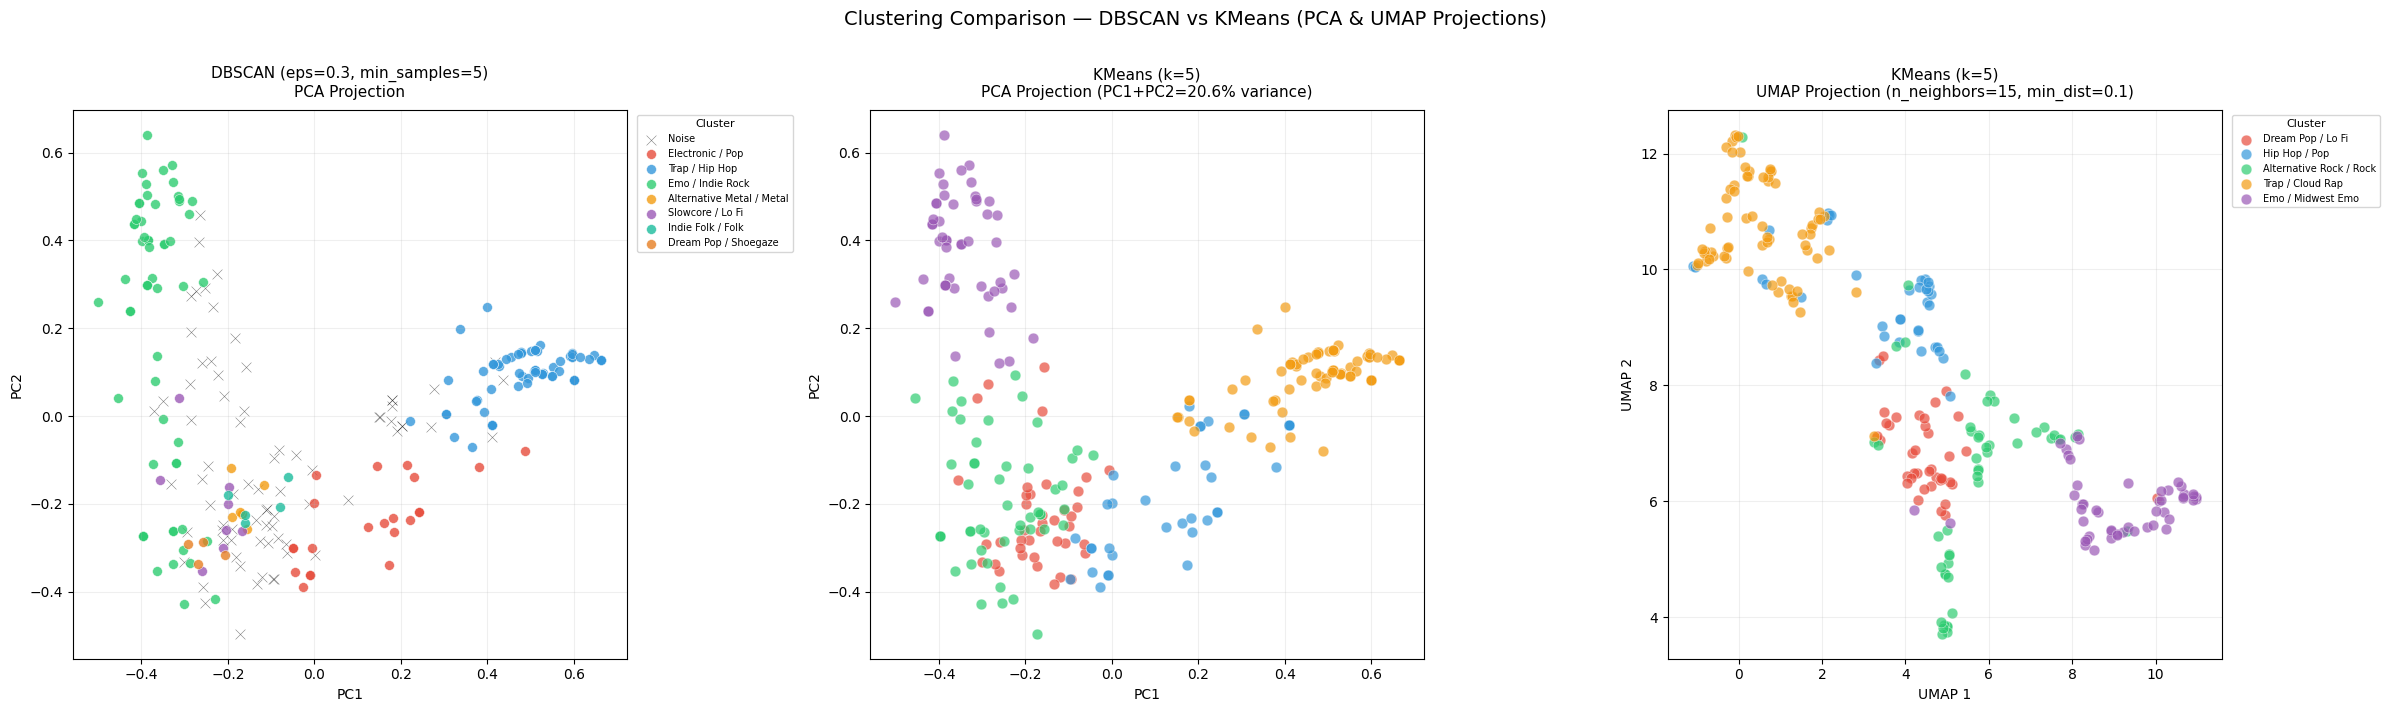

In [96]:
# Auto-name DBSCAN clusters from top 2 genres
dbscan_cluster_names = {-1: 'Noise'}
for lbl in sorted(set(labels)):
    if lbl == -1:
        continue
    subset_idx = artists_df[artists_df['DBSCAN_Cluster'] == lbl].index
    genre_means = tfidf_df.loc[subset_idx].mean().sort_values(ascending=False)
    top2 = genre_means.head(2).index.tolist()
    dbscan_cluster_names[lbl] = ' / '.join(g.replace('_', ' ').title() for g in top2)

print("DBSCAN cluster names:")
for lbl, name in dbscan_cluster_names.items():
    print(f"  Cluster {lbl}: {name}")

# Auto-name KMeans clusters from top 2 genres
kmeans_n_clusters = len(np.unique(cluster_labels))  # KMeans-specific count
kmeans_cluster_names = {}
for cls in range(kmeans_n_clusters):
    subset_idx = artists_df[artists_df['cluster'] == cls].index
    genre_means = tfidf_df.loc[subset_idx].mean().sort_values(ascending=False)
    top2 = genre_means.head(2).index.tolist()
    kmeans_cluster_names[cls] = ' / '.join(g.replace('_', ' ').title() for g in top2)

print("KMeans cluster names:")
for cls, name in kmeans_cluster_names.items():
    print(f"  Cluster {cls}: {name}")

# Fit UMAP
print("\nFitting UMAP...")
reducer_final = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_final = reducer_final.fit_transform(tfidf_df)
print("Done.")

# DBSCAN palette — 7 clusters + noise
dbscan_palette = {
    -1: 'black',
    0: '#e74c3c',
    1: '#3498db',
    2: '#2ecc71',
    3: '#f39c12',
    4: '#9b59b6',
    5: '#1abc9c',
    6: '#e67e22'
}

# 3-panel figure: DBSCAN | KMeans PCA | KMeans UMAP
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- Panel 1: DBSCAN (PCA projection) ---
for lbl in sorted(set(labels)):
    mask = labels == lbl
    axes[0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        color=dbscan_palette[lbl],
        label=dbscan_cluster_names[lbl],
        s=50, alpha=0.5 if lbl == -1 else 0.8,
        marker='x' if lbl == -1 else 'o',
        edgecolors='none' if lbl == -1 else 'white',
        linewidths=0.4
    )
axes[0].set_title(f'DBSCAN (eps=0.3, min_samples={min_samples})\nPCA Projection', fontsize=11, pad=10)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='Cluster', fontsize=7, title_fontsize=8,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].grid(True, alpha=0.2)

# --- Panel 2: KMeans (PCA projection) ---
for cls in range(len(kmeans_cluster_names)):
    mask = cluster_labels == cls
    axes[1].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        color=colors[cls],
        label=kmeans_cluster_names[cls],
        alpha=0.7, s=60,
        edgecolors='white', linewidths=0.4
    )
axes[1].set_title(f'KMeans (k=5)\nPCA Projection (PC1+PC2={sum(pca_2d.explained_variance_ratio_)*100:.1f}% variance)',
                  fontsize=11, pad=10)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.2)

# --- Panel 3: KMeans (UMAP projection) ---
for cls in range(len(kmeans_cluster_names)):
    mask = cluster_labels == cls
    axes[2].scatter(
        X_umap_final[mask, 0], X_umap_final[mask, 1],
        color=colors[cls],
        label=kmeans_cluster_names[cls],
        alpha=0.7, s=60,
        edgecolors='white', linewidths=0.4
    )
axes[2].set_title('KMeans (k=5)\nUMAP Projection (n_neighbors=15, min_dist=0.1)',
                  fontsize=11, pad=10)
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')
axes[2].legend(title='Cluster', fontsize=7, title_fontsize=8,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[2].grid(True, alpha=0.2)

plt.suptitle('Clustering Comparison — DBSCAN vs KMeans (PCA & UMAP Projections)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insights:**
- PCA explains 20.6% of the variance
- UMAP visualization is able to capture the non-linearity of genre relationships that PCA can't
- DBScan 